# Simulación de la Competencia de Locales de Comida Rápida - TP2

Este notebook simula el modelo del Trabajo Práctico 2 para determinar la mejor combinación de decisiones (publicidad, calidad, empleados, etc.) considerando lo que puedan elegir los demás grupos.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial, exp
import random

In [ ]:
# Constantes
NUM_GRUPOS = 15  # Total de grupos en el juego
LAMBDA_TOTAL = 1000  # clientes/hora total
MARGIN_BASE = 10  # $ por persona base
COST_PUB = {1: 400, 2: 250, 3: 100}
COST_CAL = {1: 2, 2: 1, 3: 0}
COST_EMP = 25  # $ por empleado por hora
COST_LUGAR = 20  # $ por lugar de espera por hora
MU_PEDIDOS = 30  # pedidos/hora por empleado
MU_PREP = 40  # pedidos/hora por empleado prep

# Lambda por posición
LAMBDA_POS = {
    1: 170, 2: 160, 3: 140, 4: 120, 5: 110,
    6: 100, 7: 100, 8: 100, 9: 100, 10: 100,
    11: 100, 12: 100, 13: 100, 14: 100, 15: 100
}

def erlang_c(c, a):
    """Calcula la probabilidad de espera en M/M/c infinito"""
    if a >= c:
        return 1
    sum_term = sum(a**k / factorial(k) for k in range(c))
    term_c = a**c / factorial(c) * c / (c - a)
    p0 = 1 / (sum_term + term_c)
    return 1 - p0 * (a**c / factorial(c)) / (c - a)

def mmck_effective_lambda(lambda_, mu, c, K):
    """Calcula lambda efectiva para M/M/c/K"""
    a = lambda_ / mu
    if a == 0:
        return lambda_
    rho = a / c
    if rho >= 1:
        return 0  # Sistema saturado
    # Calcular P0
    sum1 = sum(a**k / factorial(k) for k in range(c))
    ratio = a / c
    sum2 = (a**c / factorial(c)) * (1 - ratio**(K - c + 1)) / (1 - ratio) if ratio != 1 else (a**c / factorial(c)) * (K - c + 1)
    p0 = 1 / (sum1 + sum2)
    # P_K
    pk = p0 * (a**K) / (factorial(c) * c**(K - c))
    return lambda_ * (1 - pk)

def calcular_beneficio(decisiones, posicion, image_rank=0):
    pub, cal, emp_ped, lugares, emp_prep = decisiones
    # Factor demanda
    factor = 3 * pub + 3 * cal + 5 * image_rank
    # Posicion basada en factor (menor mejor)
    # Para simulación, posicion dada
    
    lambda_local = LAMBDA_POS[posicion]
    margin = MARGIN_BASE - COST_CAL[cal]
    
    # Sector pedidos: M/M/c/K con c=emp_ped, K=emp_ped + lugares
    K = emp_ped + lugares
    lambda_eff_ped = mmck_effective_lambda(lambda_local, MU_PEDIDOS, emp_ped, K)
    
    # Sector prep: M/M/c infinito
    if emp_prep > 0:
        a_prep = lambda_eff_ped / MU_PREP
        c_prep = emp_prep
        if a_prep < c_prep:
            wq_prep = erlang_c(c_prep, a_prep) / (c_prep * MU_PREP - lambda_eff_ped)
        else:
            wq_prep = float('inf')
    else:
        wq_prep = float('inf')
    
    # Tiempo total aproximado (no usado en primera ronda)
    # Beneficio
    ingresos = margin * lambda_eff_ped
    costos = COST_PUB[pub] + emp_ped * COST_EMP + lugares * COST_LUGAR + emp_prep * COST_EMP
    return ingresos - costos

In [7]:
# Simulación

def simular_ronda(decisiones_mias, num_sim=500):
    beneficios = []
    for _ in range(num_sim):
        decisiones_otros = []
        for _ in range(NUM_GRUPOS - 1):
            pub = random.randint(1, 3)
            cal = random.randint(1, 3)
            emp_ped = random.randint(3, 12)
            lugares = random.randint(0, 10)
            emp_prep = random.randint(1, 12)
            decisiones_otros.append((pub, cal, emp_ped, lugares, emp_prep))

        mi_factor = 3 * decisiones_mias[0] + 3 * decisiones_mias[1]  # image=0, primera ronda
        factores_otros = [3 * d[0] + 3 * d[1] for d in decisiones_otros]
        todos_factores = [mi_factor] + factores_otros
        sorted_factores = sorted(todos_factores)
        mi_posicion = sorted_factores.index(mi_factor) + 1

        beneficio = calcular_beneficio(decisiones_mias, mi_posicion)
        beneficios.append(beneficio)

    return np.mean(beneficios), np.std(beneficios)

# Espacio de búsqueda más amplio
combinaciones = []
for pub in [1, 2, 3]:
    for cal in [1, 2, 3]:
        for emp_ped in range(3, 13):
            for lugares in [0, 2, 4, 6, 8, 10]:
                for emp_prep in range(1, 13):
                    combinaciones.append((pub, cal, emp_ped, lugares, emp_prep))

print(f"Total de combinaciones a evaluar: {len(combinaciones)}")

# Primera fase: evaluación rápida sobre todas las combinaciones
resultados = []
for comb in combinaciones:
    mean_b, std_b = simular_ronda(comb, 200)
    resultados.append((comb, mean_b, std_b))

# Refinar las mejores combinaciones con más simulaciones
resultados.sort(key=lambda x: x[1], reverse=True)
top_refinar = resultados[:20]
resultados_refinados = []
for comb, _, _ in top_refinar:
    mean_b, std_b = simular_ronda(comb, 1000)
    resultados_refinados.append((comb, mean_b, std_b))

resultados_refinados.sort(key=lambda x: x[1], reverse=True)
mejor = resultados_refinados[0]
print("Mejor combinación refinada:", mejor[0])
print("Beneficio promedio refinado:", mejor[1])
print("Desviación refinada:", mejor[2])

# Guardar top 10 para análisis posterior
resultados = resultados_refinados

Total de combinaciones a evaluar: 6480
Mejor combinación refinada: (3, 1, 9, 0, 1)
Beneficio promedio refinado: 771.9231814826227
Desviación refinada: 119.32862247840397


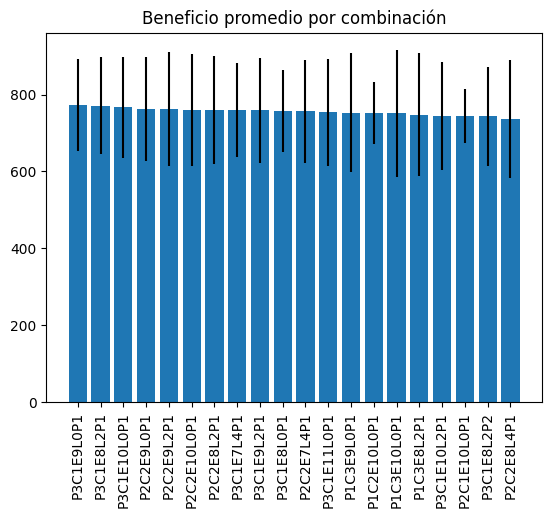

In [8]:
# Visualización
df = pd.DataFrame(resultados, columns=['Combinacion', 'Beneficio', 'Std'])
df['Label'] = df['Combinacion'].apply(lambda x: f"P{x[0]}C{x[1]}E{x[2]}L{x[3]}P{x[4]}")
plt.bar(df['Label'], df['Beneficio'], yerr=df['Std'])
plt.xticks(rotation=90)
plt.title('Beneficio promedio por combinación')
plt.show()